Test accuracy: 1.0000
w = [0.7 1.1], b = -3.299999952316284
Decision boundary: y = -0.6364 * x + 3.0000


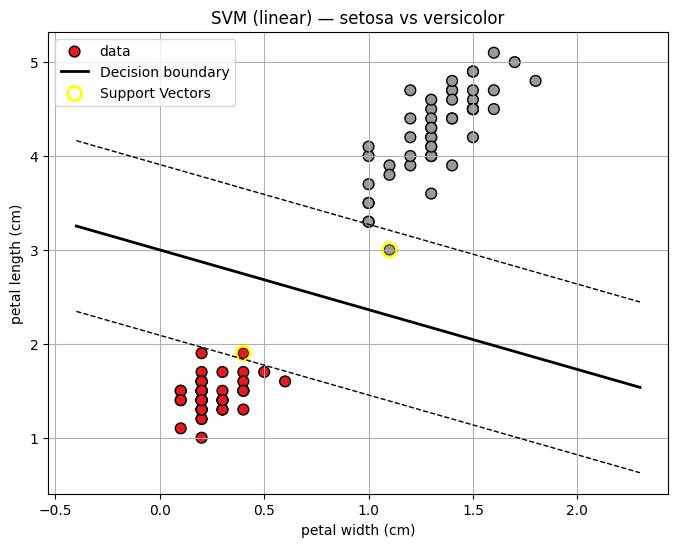

In [5]:
# SVM on Iris (petal_width vs petal_length) — binary: setosa vs versicolor
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#  بارگذاری دیتاست Iris
iris = datasets.load_iris()
X = iris.data[:, [3, 2]]   # ستون 3 = petal_width (x), ستون 2 = petal_length (y)
y = iris.target

#  انتخاب دو کلاس: setosa (0) و versicolor (1)
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

# ) تقسیم داده به train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  ساخت و آموزش SVM خطی
clf = svm.SVC(kernel='linear', C=1.0)   # اگر خواستی C رو تغییر بده
clf.fit(X_train, y_train)

#  دقت روی تست
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")

# 6 گرفتن وزن‌ها و بایاس برای معادله خط (w0 * x + w1 * y + b = 0)
w = clf.coef_[0]    # شکل (2,) چون دو ویژگی
b = clf.intercept_[0]
print(f"w = {w}, b = {b}")

# معادله خط: w0 * x + w1 * y + b = 0  =>  y = -(w0/w1) * x - b/w1
slope = -w[0] / w[1]
intercept = -b / w[1]
print(f"Decision boundary: y = {slope:.4f} * x + {intercept:.4f}")

#  رسم نقاط، خط تصمیم، margin و support vectors
plt.figure(figsize=(8,6))

# نقاط آموزشی و تست را با رنگ مختلف نشان می‌دهیم (برای دید بهتر از همه داده‌ها استفاده می‌کنیم)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Set1, edgecolor='k', s=60, label='data')

# خط تصمیم (continuous)
xx = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200)
yy = slope * xx + intercept
plt.plot(xx, yy, 'k-', linewidth=2, label='Decision boundary')

# marginها: w.x + b = ±1  => y = ( -w0*x - b ± 1 ) / w1
yy_down = ( -w[0]*xx - b - 1) / w[1]
yy_up   = ( -w[0]*xx - b + 1) / w[1]
plt.plot(xx, yy_down, 'k--', linewidth=1)
plt.plot(xx, yy_up, 'k--', linewidth=1)

# support vectors
sv = clf.support_vectors_
plt.scatter(sv[:,0], sv[:,1], s=100, facecolors='none', edgecolors='yellow', linewidths=2, label='Support Vectors')

plt.xlabel('petal width (cm)')
plt.ylabel('petal length (cm)')
plt.title('SVM (linear) — setosa vs versicolor')
plt.legend()
plt.grid(True)
plt.show()